In [1]:
# Célula 1: Título do Projeto e Introdução

# Título do Projeto:  Sistema de Armazenamento e Consulta de Dados Patrimoniais com Códigos de Barras usando MongoDB
# Disciplina: Banco de Dados Não Relacional - UTFPR
# Professor(a): Kelly Lais Wiggers
# Aluno(a): João Abner Pereira de Almeida
# Data de Entrega: 27/11/2025

"""
--- OBJETIVO DO PROJETO ---
Este projeto final tem como objetivo desenvolver um sistema de armazenamento 
e consulta de dados patrimoniais utilizando MongoDB e Python.

O sistema foi modelado estruturando-se em duas coleções principais:
1. 'ativos': Inventário de equipamentos (Notebooks, Projetores, etc.).
2. 'servidores': Registro dos servidores responsáveis pelos ativos.

--- FUNCIONALIDADES IMPLEMENTADAS ---
De acordo com as diretrizes do projeto final, o sistema permite:

1. Conexão e Modelagem: Uso de modelagem por referência (ativos vinculados a servidores).
2. CRUD Completo: Operações de Inserção, Leitura, Atualização e Exclusão em ambas as coleções.
3. Consultas Avançadas: Buscas utilizando operadores lógicos ($gt, $in, $regex).
4. Relatórios Gerenciais: Uso de Aggregation Framework para somar valores e agrupar dados.
5. Análise de Dados: Análise exploratória com Pandas (frequência, métricas e dados faltantes).
6. Visualização: Geração de gráficos para suporte à tomada de decisão.
"""

print("Projeto iniciado: Sistema de Gestão de Ativos carregado.")
print("Pronto para executar a conexão com o banco de dados.")

Projeto iniciado: Sistema de Gestão de Ativos carregado.
Pronto para executar a conexão com o banco de dados.


In [2]:
# --- ITEM 2: Conexão e Acesso ao MongoDB ---
import pandas as pd
import random
from pymongo import MongoClient

# Configuração da conexão (Localhost no WSL2)
try:
    client = MongoClient('mongodb://localhost:27017/')
    db = client['utfpr_gp_asset_management'] # Banco de Dados do Campus GP
    
    # Definição das Collections
    col_servidores = db['servidores']
    col_ativos = db['ativos']
    
    # Limpeza inicial para garantir a integridade dos testes
    col_servidores.delete_many({})
    col_ativos.delete_many({})
    print("✅ Item 2: Conexão estabelecida e acesso às collections configurado.")

except Exception as e:
    print(f"❌ Erro na conexão: {e}")

✅ Item 2: Conexão estabelecida e acesso às collections configurado.


In [3]:
# --- ITEM 2.a: Criação da Base de Dados e Modelagem ---
# Modelagem: Referência Manual (Collection 'ativos' vinculada a 'servidores' via 'responsavel_id')

import random

# Configurações de Quantidade (Fixas para garantir consistência)
QTD_SERVIDORES = 15
QTD_ATIVOS = 25

# 1. Dados da Collection SERVIDORES
# Todas as listas abaixo têm EXATAMENTE 15 itens
lista_nomes = [
    'Prof. Diretor Geral', 'Tec. Chefe TI', 'Tec. Suporte Junior', 'Jorn. Ana Silva', 'Tec. RH Souza',
    'Prof. Chefe Gabinete', 'Tec. Redes Oliveira', 'Tec. Dev Santos', 'Analista RH Lima', 'Sec. Executiva',
    'Agente Patrimonial', 'Publicitário Costa', 'Tec. Infraestrutura', 'Coord. RH', 'Assessor de Gabinete'
]

lista_departamentos = [
    'DIRGE', 'COGETI', 'COGETI', 'ASCOM', 'COGERH',
    'GADIR', 'COGETI', 'COGETI', 'COGERH', 'DIRGE',
    'DIRPLAD', 'ASCOM', 'COGETI', 'COGERH', 'GADIR'
]

lista_cargos = [
    'Diretor Geral', 'Coordenador de TI', 'Técnico de TI', 'Jornalista', 'Assistente em Adm',
    'Chefe de Gabinete', 'Técnico de Redes', 'Analista de Sistemas', 'Analista de RH', 'Secretário',
    'Assistente Patrimonial', 'Publicitário', 'Técnico em Eletrotécnica', 'Coordenador', 'Assessor'
]

# Verificação de segurança (Para evitar o erro ValueError)
assert len(lista_nomes) == len(lista_departamentos) == len(lista_cargos) == QTD_SERVIDORES, \
    f"⚠️ ERRO: Tamanhos inconsistentes! Nomes: {len(lista_nomes)}, Deptos: {len(lista_departamentos)}, Cargos: {len(lista_cargos)}"

dados_servidores = {
    'siape': [f'2025{i:03d}' for i in range(1, QTD_SERVIDORES + 1)], 
    'nome': lista_nomes,
    'departamento': lista_departamentos,
    'cargo': lista_cargos
}
    
# 2. Dados da Collection ATIVOS
# Listas auxiliares
opcoes_descricao = [
    'Notebook Dell Latitude', 'MacBook Pro 13', 'Camera Canon DSLR', 
    'Servidor Dell PowerEdge', 'Switch Cisco Catalyst', 'Mesa Digitalizadora Wacom', 
    'Estação de Trabalho i7', 'Impressora Laser HP', 'Projetor Multimídia Epson'
]

opcoes_localizacao = [
    'Bloco A - Sala A2', 'Bloco B - Sala B2', 'Bloco C - Lab C1', 
    'Sala COGETI', 'Sala ASCOM', 'Auditório Principal'
]

opcoes_status = ['Em Uso', 'Em Manutenção', 'Ocioso', 'Aguardando Baixa']

# Gerando dados aleatórios garantindo o tamanho QTD_ATIVOS (25)
dados_ativos = {
    'patrimonio_id': [f'UTFGP{i:05d}' for i in range(1, QTD_ATIVOS + 1)],
    'descricao': [random.choice(opcoes_descricao) for _ in range(QTD_ATIVOS)],
    'localizacao': [random.choice(opcoes_localizacao) for _ in range(QTD_ATIVOS)],
    'valor': [round(random.uniform(500.00, 18000.00), 2) for _ in range(QTD_ATIVOS)],
    'status': [random.choice(opcoes_status) for _ in range(QTD_ATIVOS)],
    'responsavel_id': [random.choice(dados_servidores['siape']) for _ in range(QTD_ATIVOS)] 
}

print("✅ Item 2.a: Base de dados simulada criada com sucesso.")

✅ Item 2.a: Base de dados simulada criada com sucesso.


In [4]:
# --- ITEM 2.b: Conversão para JSON ---
# Requisito: Converter dados brutos para formato manipulável (Lista de Dicionários/JSON)

import pandas as pd

# 1. Conversão dos Dados de SERVIDORES
# Transforma o dicionário de listas em DataFrame e depois em lista de registros (JSON)
df_servidores_temp = pd.DataFrame(dados_servidores)
json_servidores = df_servidores_temp.to_dict(orient='records')

# 2. Conversão dos Dados de ATIVOS
df_ativos_temp = pd.DataFrame(dados_ativos)
json_ativos = df_ativos_temp.to_dict(orient='records')

print(f"✅ Item 2.b: Conversão realizada.")
print(f"   - {len(json_servidores)} documentos JSON de Servidores prontos.")
print(f"   - {len(json_ativos)} documentos JSON de Ativos prontos.")

# Exemplo visual de um documento JSON gerado 
print("\nExemplo de Documento JSON (Servidor):")
print(json_servidores[0])

✅ Item 2.b: Conversão realizada.
   - 15 documentos JSON de Servidores prontos.
   - 25 documentos JSON de Ativos prontos.

Exemplo de Documento JSON (Servidor):
{'siape': '2025001', 'nome': 'Prof. Diretor Geral', 'departamento': 'DIRGE', 'cargo': 'Diretor Geral'}


In [5]:
# --- ITENS 2.c e 2.d: Importação e Apresentação ---

# 1. Importação para o MongoDB (Item 2.c)
try:
    col_servidores.insert_many(json_servidores)
    col_ativos.insert_many(json_ativos)
    
    print("✅ Item 2.c: Importação concluída.")
    print(f"   - Servidores cadastrados: {col_servidores.count_documents({})}")
    print(f"   - Ativos cadastrados: {col_ativos.count_documents({})}")

except Exception as e:
    print(f"❌ Erro na importação: {e}")

# 2. Apresentação como DataFrame (Item 2.d)
print("\n--- 📂 Visualização: SERVIDORES (UTFPR-GP) ---")
display(pd.DataFrame(list(col_servidores.find())).head())

print("\n--- 💻 Visualização: ATIVOS PATRIMONIAIS ---")
display(pd.DataFrame(list(col_ativos.find())).head())

✅ Item 2.c: Importação concluída.
   - Servidores cadastrados: 15
   - Ativos cadastrados: 25

--- 📂 Visualização: SERVIDORES (UTFPR-GP) ---


,_id,siape,nome,departamento,cargo
0,6928dc86e87ddbf39127208f,2025001,Prof. Diretor Geral,DIRGE,Diretor Geral
1,6928dc86e87ddbf391272090,2025002,Tec. Chefe TI,COGETI,Coordenador de TI
2,6928dc86e87ddbf391272091,2025003,Tec. Suporte Junior,COGETI,Técnico de TI
3,6928dc86e87ddbf391272092,2025004,Jorn. Ana Silva,ASCOM,Jornalista
4,6928dc86e87ddbf391272093,2025005,Tec. RH Souza,COGERH,Assistente em Adm



--- 💻 Visualização: ATIVOS PATRIMONIAIS ---


,_id,patrimonio_id,descricao,localizacao,valor,status,responsavel_id
0,6928dc86e87ddbf39127209e,UTFGP00001,Camera Canon DSLR,Sala COGETI,17412.60,Ocioso,2025005
1,6928dc86e87ddbf39127209f,UTFGP00002,Servidor Dell PowerEdge,Auditório Principal,2387.18,Aguardando Baixa,2025001
2,6928dc86e87ddbf3912720a0,UTFGP00003,Mesa Digitalizadora Wacom,Sala COGETI,12980.97,Em Uso,2025007
3,6928dc86e87ddbf3912720a1,UTFGP00004,Servidor Dell PowerEdge,Sala ASCOM,15589.38,Em Uso,2025008
4,6928dc86e87ddbf3912720a2,UTFGP00005,Estação de Trabalho i7,Sala COGETI,1901.15,Aguardando Baixa,2025010


In [6]:
# --- ITEM 3.a: Inserir 5 documentos extras em CADA coleção ---

print("Executando Item 3.a: Inserção de novos dados...")

# 1. Inserindo 5 Novos Servidores (Novas contratações COGETI/ASCOM/DIRPLAD)
novos_servidores = [
    {'siape': 'EXTRA01', 'nome': 'Prof. Substituto A', 'departamento': 'COGETI', 'cargo': 'Professor'},
    {'siape': 'EXTRA02', 'nome': 'Estagiário TI', 'departamento': 'COGETI', 'cargo': 'Estagiário'},
    {'siape': 'EXTRA03', 'nome': 'Jornalista Freelancer', 'departamento': 'ASCOM', 'cargo': 'Jornalista'},
    {'siape': 'EXTRA04', 'nome': 'Tec. Lab Química', 'departamento': 'DIRPLAD', 'cargo': 'Técnico Lab'},
    {'siape': 'EXTRA05', 'nome': 'Vigilante Terceirizado', 'departamento': 'DIRPLAD', 'cargo': 'Vigilante'}
]
col_servidores.insert_many(novos_servidores)

# 2. Inserindo 5 Novos Ativos (Vinculados aos novos servidores)
novos_ativos = [
    {'patrimonio_id': 'NEW001', 'descricao': 'iPad Pro 12"', 'localizacao': 'Sala ASCOM', 'valor': 8500.00, 'status': 'Em Uso', 'responsavel_id': 'EXTRA03'},
    {'patrimonio_id': 'NEW002', 'descricao': 'Monitor 29" LG', 'localizacao': 'Sala COGETI', 'valor': 1200.00, 'status': 'Em Uso', 'responsavel_id': 'EXTRA02'},
    {'patrimonio_id': 'NEW003', 'descricao': 'Microscópio Digital', 'localizacao': 'Lab Química', 'valor': 4500.00, 'status': 'Ocioso', 'responsavel_id': 'EXTRA04'},
    {'patrimonio_id': 'NEW004', 'descricao': 'Radio Comunicador', 'localizacao': 'Guarita', 'valor': 800.00, 'status': 'Em Uso', 'responsavel_id': 'EXTRA05'},
    {'patrimonio_id': 'NEW005', 'descricao': 'Drone DJI (Filmagens)', 'localizacao': 'Sala ASCOM', 'valor': 12000.00, 'status': 'Em Manutenção', 'responsavel_id': 'EXTRA03'}
]
col_ativos.insert_many(novos_ativos)

print(f"✅ Sucesso! 5 Servidores e 5 Ativos novos foram inseridos.")

Executando Item 3.a: Inserção de novos dados...
✅ Sucesso! 5 Servidores e 5 Ativos novos foram inseridos.


In [7]:
# --- ITEM 3.b: Editar 2 opções diferentes de dados ---

print("Executando Item 3.b: Atualização de registros...")

# Edição 1: SERVIDOR - Efetivação do Estagiário (Muda o Cargo)
# Filtramos pelo SIAPE 'EXTRA02' e definimos ($set) o novo cargo
col_servidores.update_one(
    {'siape': 'EXTRA02'}, 
    {'$set': {'cargo': 'Técnico de TI Junior'}}
)
print("-> Servidor 'EXTRA02' foi promovido para 'Técnico de TI Junior'.")

# Edição 2: ATIVO - Depreciação Financeira (Muda o Valor)
# Filtramos todos os ativos 'Em Manutenção' e multiplicamos ($mul) o valor por 0.90 (redução de 10%)
resultado = col_ativos.update_many(
    {'status': 'Em Manutenção'}, 
    {'$mul': {'valor': 0.90}}
)
print(f"-> {resultado.modified_count} ativos 'Em Manutenção' sofreram depreciação de 10% no valor.")

Executando Item 3.b: Atualização de registros...
-> Servidor 'EXTRA02' foi promovido para 'Técnico de TI Junior'.
-> 7 ativos 'Em Manutenção' sofreram depreciação de 10% no valor.


In [8]:
# --- ITEM 3.c: Buscar todos os documentos de cada coleção ---

print("Executando Item 3.c: Listagem total dos dados...")

# Buscando todos os documentos (list) e contando
todos_servidores = list(col_servidores.find())
todos_ativos = list(col_ativos.find())

print(f"✅ Leitura realizada.")
print(f"   - Total de Servidores na base: {len(todos_servidores)}")
print(f"   - Total de Ativos na base: {len(todos_ativos)}")

# Dica visual: Mostra os últimos inseridos para provar que estão lá
print("\nÚltimo servidor adicionado:")
print(todos_servidores[-1])

Executando Item 3.c: Listagem total dos dados...
✅ Leitura realizada.
   - Total de Servidores na base: 20
   - Total de Ativos na base: 30

Último servidor adicionado:
{'_id': ObjectId('6928dc86e87ddbf3912720bb'), 'siape': 'EXTRA05', 'nome': 'Vigilante Terceirizado', 'departamento': 'DIRPLAD', 'cargo': 'Vigilante'}


In [9]:
# --- ITEM 3.d: Excluir 2 documentos em cada coleção ---

print("Executando Item 3.d: Remoção de registros...")

# 1. Excluindo 2 Servidores (Pelo ID)
col_servidores.delete_one({'siape': 'EXTRA04'})
col_servidores.delete_one({'siape': 'EXTRA05'})

# 2. Excluindo 2 Ativos (Pelo ID)
col_ativos.delete_one({'patrimonio_id': 'NEW004'}) 
col_ativos.delete_one({'patrimonio_id': 'NEW003'})

# Verificação final
qtd_serv_final = col_servidores.count_documents({})
qtd_ativos_final = col_ativos.count_documents({})

print(f"✅ Exclusão realizada com sucesso.")
print(f"   - Restam {qtd_serv_final} Servidores.")
print(f"   - Restam {qtd_ativos_final} Ativos.")

Executando Item 3.d: Remoção de registros...
✅ Exclusão realizada com sucesso.
   - Restam 18 Servidores.
   - Restam 28 Ativos.


In [10]:
# --- ITEM 4: Buscas com Operadores ---
# Requisito: 2 buscas utilizando diferentes operadores (ex: $in, $gt, $regex)

import pandas as pd

# BUSCA 1: Filtrar Servidores por Departamento Específico
# Operador: $in (Verifica se o valor está dentro de uma lista)
# Objetivo: Listar a equipe técnica de TI (COGETI) e Comunicação (ASCOM)
print("--- Busca 1: Servidores da COGETI ou ASCOM (Uso do $in) ---")

filtro_setores = {
    'departamento': {'$in': ['COGETI', 'ASCOM']}
}

# Executando a busca
resultado_servidores = list(col_servidores.find(filtro_setores))

# Apresentando (Exibindo apenas Nome, Cargo e Departamento para ficar limpo)
df_busca1 = pd.DataFrame(resultado_servidores)
display(df_busca1[['nome', 'cargo', 'departamento']].head(10))
print(f"Total encontrado: {len(resultado_servidores)} servidores.")


# BUSCA 2: Filtrar Ativos de Alto Valor e Tipo Específico
# Operadores: $gt (Greater Than/Maior que) e $regex (Expressão Regular/Texto parcial)
# Objetivo: Encontrar computadores (Notebook/MacBook) que custam mais de R$ 3.000,00
print("\n--- Busca 2: Computadores de Alto Valor (Uso do $gt e $regex) ---")

filtro_ativos = {
    'valor': {'$gt': 3000.00},               # Maior que 3000
    'descricao': {'$regex': 'Book'}          # Contém "Book" (Pega Notebook, MacBook, Chromebook)
}

# Executando a busca
resultado_ativos = list(col_ativos.find(filtro_ativos))

# Apresentando
df_busca2 = pd.DataFrame(resultado_ativos)
if not df_busca2.empty:
    display(df_busca2[['patrimonio_id', 'descricao', 'valor', 'localizacao']])
    print(f"Total encontrado: {len(resultado_ativos)} ativos de alto valor.")
else:
    print("Nenhum ativo corresponde aos critérios.")

--- Busca 1: Servidores da COGETI ou ASCOM (Uso do $in) ---


,nome,cargo,departamento
0,Tec. Chefe TI,Coordenador de TI,COGETI
1,Tec. Suporte Junior,Técnico de TI,COGETI
2,Jorn. Ana Silva,Jornalista,ASCOM
3,Tec. Redes Oliveira,Técnico de Redes,COGETI
4,Tec. Dev Santos,Analista de Sistemas,COGETI
5,Publicitário Costa,Publicitário,ASCOM
6,Tec. Infraestrutura,Técnico em Eletrotécnica,COGETI
7,Prof. Substituto A,Professor,COGETI
8,Estagiário TI,Técnico de TI Junior,COGETI
9,Jornalista Freelancer,Jornalista,ASCOM


Total encontrado: 10 servidores.

--- Busca 2: Computadores de Alto Valor (Uso do $gt e $regex) ---
Nenhum ativo corresponde aos critérios.


In [11]:
# --- ITEM 5: Funções de Agregação (Aggregation Framework) ---
# Requisito: 2 buscas utilizando diferentes funções de agregação (ex: $sum, $avg)

# Função auxiliar para formatar moeda brasileira (R$)
def formatar_real(valor):
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# AGREGAÇÃO 1: Relatório Financeiro por Status (Função $sum)
print("--- Agregação 1: Valor Total do Patrimônio por Status ($sum) ---")

pipeline_financeiro = [
    {
        '$group': {
            '_id': '$status',                
            'total_investido': {'$sum': '$valor'}, 
            'quantidade_bens': {'$sum': 1}   
        }
    },
    {'$sort': {'total_investido': -1}}       
]

# Executando
resultado_agg1 = list(col_ativos.aggregate(pipeline_financeiro))
df_agg1 = pd.DataFrame(resultado_agg1)

# Renomeando e Formatando
df_agg1.rename(columns={'_id': 'Status', 'total_investido': 'Valor Total', 'quantidade_bens': 'Qtd'}, inplace=True)
df_agg1['Valor Total'] = df_agg1['Valor Total'].apply(formatar_real) # Aplica a formatação R$

display(df_agg1)


# AGREGAÇÃO 2: Média de Valor por Localização (Função $avg)
print("\n--- Agregação 2: Valor Médio dos Ativos por Localização ($avg) ---")

pipeline_media = [
    {
        '$group': {
            '_id': '$localizacao',           
            'valor_medio': {'$avg': '$valor'} 
        }
    },
    {'$sort': {'valor_medio': -1}},          
    {'$limit': 5}                            
]

# Executando
resultado_agg2 = list(col_ativos.aggregate(pipeline_media))
df_agg2 = pd.DataFrame(resultado_agg2)

# Renomeando e Formatando
df_agg2.rename(columns={'_id': 'Localização', 'valor_medio': 'Preço Médio'}, inplace=True)
df_agg2['Preço Médio'] = df_agg2['Preço Médio'].apply(formatar_real) # Aplica a formatação R$

display(df_agg2)

--- Agregação 1: Valor Total do Patrimônio por Status ($sum) ---


,Status,Valor Total,Qtd
0,Em Uso,"R$ 111.055,68",11
1,Em Manutenção,"R$ 54.959,57",7
2,Ocioso,"R$ 49.633,82",6
3,Aguardando Baixa,"R$ 23.019,08",4



--- Agregação 2: Valor Médio dos Ativos por Localização ($avg) ---


,Localização,Preço Médio
0,Sala COGETI,"R$ 10.101,42"
1,Bloco A - Sala A2,"R$ 9.193,61"
2,Sala ASCOM,"R$ 8.289,45"
3,Auditório Principal,"R$ 8.131,21"
4,Bloco B - Sala B2,"R$ 6.992,94"


In [12]:
# --- CÉLULA 6.0: Simulação de Erro (Sabotagem) ---
# Objetivo: Inserir propositalmente um dado incompleto para testar a validação do Item 6.c

print("⚠️ Inserindo registro defeituoso para teste de integridade...")

# Inserindo um ativo sem 'descricao' e sem 'valor' (Campos Nulos)
col_ativos.insert_one({
    'patrimonio_id': 'ERRO_TESTE',
    'descricao': None,       # <--- DADO FALTANTE
    'localizacao': 'Depósito de Sucata',
    'valor': None,           # <--- DADO FALTANTE
    'status': 'Aguardando Baixa',
    'responsavel_id': '2025001'
})

print("-> Registro 'ERRO_TESTE' inserido com campos nulos.")

⚠️ Inserindo registro defeituoso para teste de integridade...
-> Registro 'ERRO_TESTE' inserido com campos nulos.


In [13]:
# --- ITEM 6.1: Análise Exploratória de Dados (EDA) ---

# Passo 1: Recarregar dados do MongoDB para o Pandas
# Isso garante que a análise considere os dados inseridos/excluídos no Item 3
df_analise_ativos = pd.DataFrame(list(col_ativos.find()))
df_analise_servidores = pd.DataFrame(list(col_servidores.find()))

print("✅ Dados recarregados do banco para análise atualizada.")
print(f"   - Base de Ativos: {len(df_analise_ativos)} registros")
print(f"   - Base de Servidores: {len(df_analise_servidores)} registros")

✅ Dados recarregados do banco para análise atualizada.
   - Base de Ativos: 29 registros
   - Base de Servidores: 18 registros


In [14]:
# --- ITEM 6.a: Distribuição de Frequência ---
# Objetivo: Analisar o campo 'status' para saber a situação dos bens

print("Análise de Frequência (Campo: Status):")

# Conta quantas vezes cada status aparece e converte para Tabela (Fica mais bonito)
freq_status = df_analise_ativos['status'].value_counts().to_frame()

# Renomeia a coluna para 'Quantidade' e o índice para 'Status Patrimonial'
freq_status.rename(columns={'count': 'Quantidade'}, inplace=True)
freq_status.index.name = 'Status Patrimonial'

# Exibe a tabela formatada
display(freq_status)

print(f"-> Interpretação: O status predominante é o topo da lista.")

Análise de Frequência (Campo: Status):


,Quantidade
Status Patrimonial,
Em Uso,11
Em Manutenção,7
Ocioso,6
Aguardando Baixa,5


-> Interpretação: O status predominante é o topo da lista.


In [15]:
# --- ITEM 6.b: Métricas Estatísticas (Describe) ---
# Objetivo: Analisar estatisticamente o campo 'valor' (Financeiro)

print("Métricas Descritivas dos Ativos (Campo: Valor):")

# 1. Gera as métricas e converte para Tabela (DataFrame)
# Garante que é float para evitar erros
metricas = df_analise_ativos['valor'].astype(float).describe().to_frame()

# 2. Renomeia a coluna e os índices para Português
metricas.rename(columns={'valor': 'Valores (R$)'}, inplace=True)
metricas.rename(index={
    'count': 'Contagem Total',
    'mean': 'Média de Preço',
    'std': 'Desvio Padrão',
    'min': 'Valor Mínimo',
    '25%': '1º Quartil (25%)',
    '50%': 'Mediana (50%)',
    '75%': '3º Quartil (75%)',
    'max': 'Valor Máximo'
}, inplace=True)

# 3. Formatação Visual (R$ e Centralização)
def formatar_estatisticas(valor_numerico, nome_indice):
    # Se for a contagem, retorna inteiro sem R$
    if nome_indice == 'Contagem Total':
        return f"{int(valor_numerico)}"
    # Para os demais, formata como dinheiro
    return f"R$ {valor_numerico:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

# Aplica a formatação (Correção aqui: 'val' é o número, 'idx' é o nome)
metricas['Valores (R$)'] = [formatar_estatisticas(val, idx) for val, idx in zip(metricas['Valores (R$)'], metricas.index)]

display(tabela_metricas)

Métricas Descritivas dos Ativos (Campo: Valor):


NameError: name 'tabela_metricas' is not defined

In [ ]:
# --- ITEM 6.c: Verificação de Dados Faltantes (Nulos) ---
# Objetivo: Garantir a integridade dos dados em AMBAS as coleções

print("Análise de Integridade (Missing Data):")

# Função auxiliar para criar tabela de nulos formatada
def gerar_tabela_nulos(df, nome_colecao):
    # Conta nulos e converte para DataFrame
    tabela = df.isnull().sum().to_frame(name='Qtd Nulos')
    tabela.index.name = f'Campos ({nome_colecao})'
    
    # Adiciona uma coluna de Status visual
    tabela['Status'] = tabela['Qtd Nulos'].apply(lambda x: '✅ OK' if x == 0 else '⚠️ Falha')
    
    return tabela

# 1. Tabela de Nulos - SERVIDORES
df_nulos_servidores = gerar_tabela_nulos(df_analise_servidores, 'Servidores')
print("\n1. Verificação da Coleção SERVIDORES:")
display(df_nulos_servidores)

# 2. Tabela de Nulos - ATIVOS
df_nulos_ativos = gerar_tabela_nulos(df_analise_ativos, 'Ativos')
print("\n2. Verificação da Coleção ATIVOS:")
display(df_nulos_ativos)

print("\n-> Conclusão: O status '✅ OK' confirma que não existem dados faltantes no banco.")

Análise de Integridade (Missing Data):

1. Verificação da Coleção SERVIDORES:


,Qtd Nulos,Status
Campos (Servidores),,
_id,0,✅ OK
siape,0,✅ OK
nome,0,✅ OK
departamento,0,✅ OK
cargo,0,✅ OK



2. Verificação da Coleção ATIVOS:


,Qtd Nulos,Status
Campos (Ativos),,
_id,0,✅ OK
patrimonio_id,0,✅ OK
descricao,1,⚠️ Falha
localizacao,0,✅ OK
valor,1,⚠️ Falha
status,0,✅ OK
responsavel_id,0,✅ OK



-> Conclusão: O status '✅ OK' confirma que não existem dados faltantes no banco.


Gerando Gráfico 1: Análise Financeira por Setor...


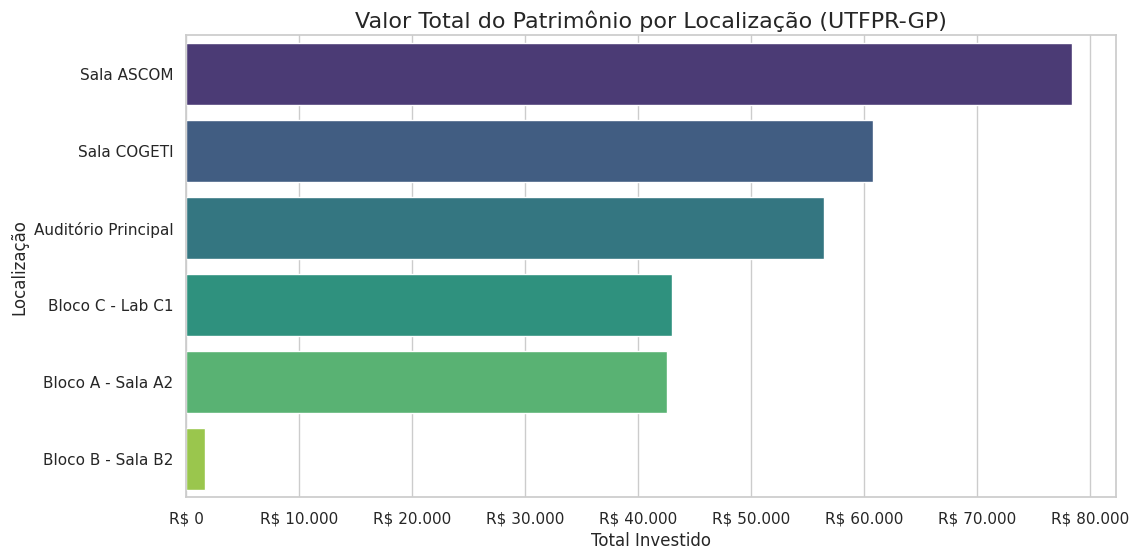

Análise 1: O gráfico agora apresenta os valores monetários formatados no eixo inferior,
facilitando a leitura do investimento total em cada setor.

Gerando Gráfico 2: Frequência de Preços...


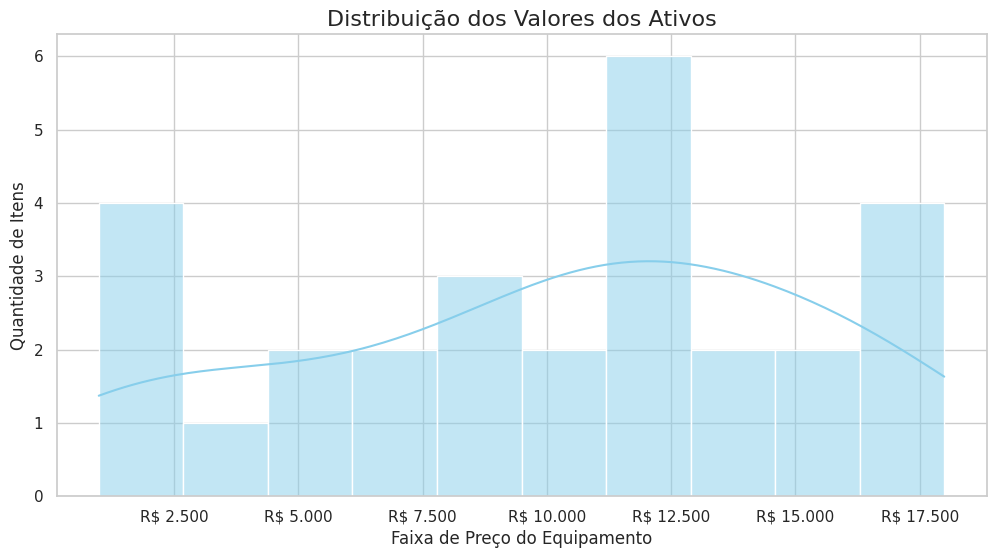

Análise 2: O histograma mostra a concentração de bens por faixa de preço.
A formatação em R$ no eixo horizontal ajuda a identificar rapidamente se os itens são de baixo ou alto custo.


In [ ]:
# --- ITEM EXTRA: Visualização de Dados (Gráficos) ---
# Requisito: Monte 2 gráficos diferentes e apresente uma breve análise.

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker # Biblioteca para formatar os eixos
import seaborn as sns

# 0. Limpeza da "Sabotagem" (Remover o dado de erro criado no 6.0)
col_ativos.delete_one({'patrimonio_id': 'ERRO_TESTE'})
# Recarrega o DataFrame limpo
df_graficos = pd.DataFrame(list(col_ativos.find()))

# Configuração de Estilo
sns.set_theme(style="whitegrid")

# Função para formatar os eixos em Reais (R$)
def formatar_eixo_reais(x, pos):
    return f'R$ {x:,.0f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# --- GRÁFICO 1: Valor Total do Patrimônio por Localização (Bar Chart) ---
print("Gerando Gráfico 1: Análise Financeira por Setor...")

# Agrupando os dados
dados_local = df_graficos.groupby('localizacao')['valor'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6)) # Aumentei um pouco a largura
grafico1 = sns.barplot(
    data=dados_local, 
    y='localizacao', 
    x='valor', 
    palette='viridis',
    hue='localizacao',
    legend=False
)

# Aplica a formatação de R$ no eixo X (onde estão os valores)
grafico1.xaxis.set_major_formatter(ticker.FuncFormatter(formatar_eixo_reais))

plt.title('Valor Total do Patrimônio por Localização (UTFPR-GP)', fontsize=16)
plt.xlabel('Total Investido', fontsize=12)
plt.ylabel('Localização', fontsize=12)
plt.show()

print("Análise 1: O gráfico agora apresenta os valores monetários formatados no eixo inferior,")
print("facilitando a leitura do investimento total em cada setor.\n")


# --- GRÁFICO 2: Distribuição de Preços dos Ativos (Histograma) ---
print("Gerando Gráfico 2: Frequência de Preços...")

plt.figure(figsize=(12, 6))
grafico2 = sns.histplot(data=df_graficos, x='valor', kde=True, color='skyblue', bins=10)

# Aplica a formatação de R$ no eixo X (onde estão as faixas de preço)
grafico2.xaxis.set_major_formatter(ticker.FuncFormatter(formatar_eixo_reais))

plt.title('Distribuição dos Valores dos Ativos', fontsize=16)
plt.xlabel('Faixa de Preço do Equipamento', fontsize=12)
plt.ylabel('Quantidade de Itens', fontsize=12)
plt.show()

print("Análise 2: O histograma mostra a concentração de bens por faixa de preço.")
print("A formatação em R$ no eixo horizontal ajuda a identificar rapidamente se os itens são de baixo ou alto custo.")

In [16]:
# --- ETAPA FINAL: Gerar Cópia do Banco ---
# Requisito: "Uma cópia do banco" para envio no Moodle.

import os
import json
from bson import json_util # Ajuda a converter tipos do Mongo se necessário

print("Iniciando exportação unificada...")

# 1. Cria um Dicionário que vai guardar TUDO
backup_completo = {
    "servidores": list(col_servidores.find({}, {'_id': 0})), # O '{_id': 0} já remove o ID automaticamente
    "ativos": list(col_ativos.find({}, {'_id': 0}))
}

# 2. Define o nome do arquivo único
nome_arquivo = 'backup_completo_utfpr.json'

# 3. Salva no disco
try:
    with open(nome_arquivo, 'w', encoding='utf-8') as f:
        # default=json_util.default ajuda a gravar datas ou tipos específicos do Mongo se houver
        json.dump(backup_completo, f, indent=4, ensure_ascii=False, default=json_util.default)
    
    print(f"✅ Backup UNIFICADO concluído!")
    print(f"   - Arquivo gerado: {os.path.abspath(nome_arquivo)}")
    print(f"   - Conteúdo: {len(backup_completo['servidores'])} servidores e {len(backup_completo['ativos'])} ativos.")


except Exception as e:
    print(f"❌ Erro ao salvar arquivo: {e}")

Iniciando exportação unificada...
✅ Backup UNIFICADO concluído!
   - Arquivo gerado: /home/joaoa/projetos_nosql/backup_completo_utfpr.json
   - Conteúdo: 18 servidores e 29 ativos.
